In [3]:
import pandas as pd
import numpy as np

In [4]:
print(pd.__version__)
print(np.__version__)

2.3.3
2.3.5


In [5]:
df = pd.read_csv("Week_1_Raw_Customer_Churn_Dataset.csv")

In [6]:
df.head()

,CustomerID,Age,Gender,City,TenureMonths,MonthlyCharges,ContractType,PaymentMethod,Churn
0,1001,22.0,Female,Delhi,3,899,Monthly,UPI,Yes
1,1002,35.0,Male,Mumbai,24,1299,Annual,Card,No
2,1003,41.0,Female,Delhi,36,1599,Annual,UPI,No
3,1004,29.0,Male,Bengaluru,8,999,Monthly,Cash,Yes
4,1005,52.0,Female,Mumbai,48,1899,Annual,Card,No


In [7]:
df.shape

(30, 9)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerID      30 non-null     int64  
 1   Age             28 non-null     float64
 2   Gender          29 non-null     object 
 3   City            30 non-null     object 
 4   TenureMonths    30 non-null     int64  
 5   MonthlyCharges  30 non-null     int64  
 6   ContractType    30 non-null     object 
 7   PaymentMethod   30 non-null     object 
 8   Churn           30 non-null     object 
dtypes: float64(1), int64(3), object(5)
memory usage: 2.2+ KB


In [9]:
df.isnull().sum()

CustomerID        0
Age               2
Gender            1
City              0
TenureMonths      0
MonthlyCharges    0
ContractType      0
PaymentMethod     0
Churn             0
dtype: int64

In [10]:
df[df.isnull().any(axis=1)]

,CustomerID,Age,Gender,City,TenureMonths,MonthlyCharges,ContractType,PaymentMethod,Churn
7,1008,NaN,Male,Delhi,30,1199,Annual,Card,No
9,1010,38.0,NaN,Mumbai,42,1699,Annual,Card,No
14,1015,NaN,Female,Mumbai,4,999,Monthly,Cash,Yes


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["Age"].median()

37.5

In [13]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [14]:
df["Age"].isnull().sum()

np.int64(0)

In [15]:
df["Gender"].mode()[0]

'Female'

In [16]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

In [17]:
df["Gender"].isnull().sum()

np.int64(0)

In [18]:
df.isnull().sum()

CustomerID        0
Age               0
Gender            0
City              0
TenureMonths      0
MonthlyCharges    0
ContractType      0
PaymentMethod     0
Churn             0
dtype: int64

In [19]:
df.head(10)

,CustomerID,Age,Gender,City,TenureMonths,MonthlyCharges,ContractType,PaymentMethod,Churn
0,1001,22.0,Female,Delhi,3,899,Monthly,UPI,Yes
1,1002,35.0,Male,Mumbai,24,1299,Annual,Card,No
2,1003,41.0,Female,Delhi,36,1599,Annual,UPI,No
3,1004,29.0,Male,Bengaluru,8,999,Monthly,Cash,Yes
4,1005,52.0,Female,Mumbai,48,1899,Annual,Card,No
5,1006,46.0,Male,Delhi,18,1499,Annual,UPI,No
6,1007,31.0,Female,Kolkata,5,799,Monthly,Cash,Yes
7,1008,37.5,Male,Delhi,30,1199,Annual,Card,No
8,1009,27.0,Female,Pune,12,1099,Monthly,UPI,Yes
9,1010,38.0,Female,Mumbai,42,1699,Annual,Card,No


In [20]:
X = df.drop(columns=["CustomerID", "Churn"])
y = df["Churn"]

In [21]:
X.head()

,Age,Gender,City,TenureMonths,MonthlyCharges,ContractType,PaymentMethod
0,22.0,Female,Delhi,3,899,Monthly,UPI
1,35.0,Male,Mumbai,24,1299,Annual,Card
2,41.0,Female,Delhi,36,1599,Annual,UPI
3,29.0,Male,Bengaluru,8,999,Monthly,Cash
4,52.0,Female,Mumbai,48,1899,Annual,Card


In [22]:
X.dtypes

Age               float64
Gender             object
City               object
TenureMonths        int64
MonthlyCharges      int64
ContractType       object
PaymentMethod      object
dtype: object

In [23]:
X_encoded = X.copy()

In [24]:
categorical_columns = ["Gender", "City", "ContractType", "PaymentMethod"]

X_encoded = pd.get_dummies(
    X_encoded,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

In [25]:
X_encoded.head()

,Age,TenureMonths,MonthlyCharges,Gender_Male,City_Delhi,City_Kolkata,City_Mumbai,City_Pune,ContractType_Monthly,PaymentMethod_Cash,PaymentMethod_UPI
0,22.0,3,899,0,1,0,0,0,1,0,1
1,35.0,24,1299,1,0,0,1,0,0,0,0
2,41.0,36,1599,0,1,0,0,0,0,0,1
3,29.0,8,999,1,0,0,0,0,1,1,0
4,52.0,48,1899,0,0,0,1,0,0,0,0


In [26]:
X_encoded.shape

(30, 11)

In [28]:
from sklearn.preprocessing import MinMaxScaler

In [29]:
scaler = MinMaxScaler()

In [30]:
numerical_columns = ["Age", "TenureMonths", "MonthlyCharges"]

X_encoded[numerical_columns] = scaler.fit_transform(
    X_encoded[numerical_columns]
)

In [31]:
X_encoded.head()

,Age,TenureMonths,MonthlyCharges,Gender_Male,City_Delhi,City_Kolkata,City_Mumbai,City_Pune,ContractType_Monthly,PaymentMethod_Cash,PaymentMethod_UPI
0,0.000000,0.000000,0.071429,0,1,0,0,0,1,0,1
1,0.333333,0.368421,0.357143,1,0,0,1,0,0,0,0
2,0.487179,0.578947,0.571429,0,1,0,0,0,0,0,1
3,0.179487,0.087719,0.142857,1,0,0,0,0,1,1,0
4,0.769231,0.789474,0.785714,0,0,0,1,0,0,0,0


In [32]:
X_encoded.isnull().sum().sum()

np.int64(0)

In [36]:
y.value_counts()

Churn
No     18
Yes    12
Name: count, dtype: int64

<Axes: title={'center': 'Customer Churn Distribution'}, xlabel='Churn'>

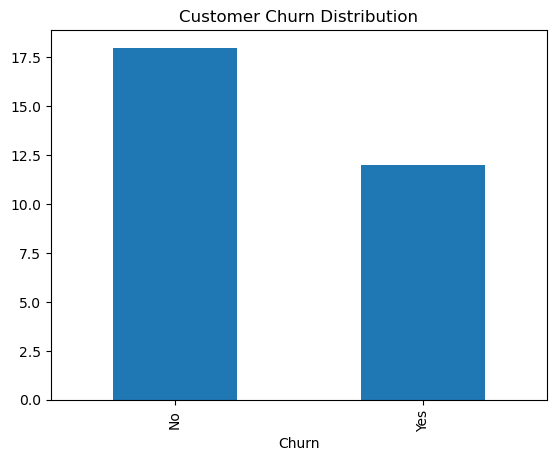

In [37]:
y.value_counts().plot(kind="bar", title="Customer Churn Distribution")

In [39]:
import matplotlib.pyplot as plt
plt.show()

<Axes: title={'center': 'Age Distribution'}, ylabel='Frequency'>

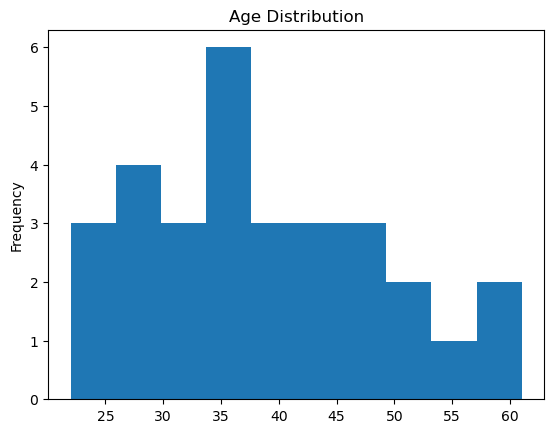

In [40]:
df["Age"].plot(kind="hist", title="Age Distribution")

<Axes: title={'center': 'Monthly Charges Distribution'}, ylabel='Frequency'>

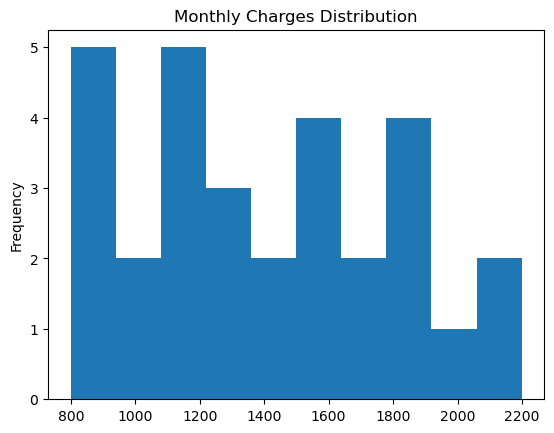

In [41]:
df["MonthlyCharges"].plot(kind="hist", title="Monthly Charges Distribution")

<Axes: title={'center': 'Churn by Contract Type'}, xlabel='ContractType'>

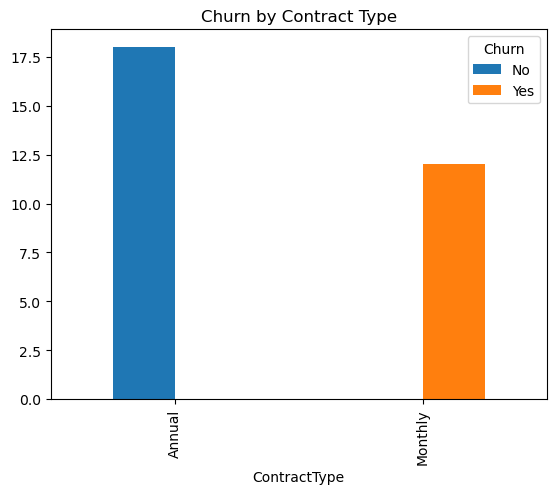

In [42]:
pd.crosstab(df["ContractType"], df["Churn"]).plot(kind="bar", title="Churn by Contract Type")

In [43]:
df.describe()

,CustomerID,Age,TenureMonths,MonthlyCharges
count,30.000000,30.000000,30.000000,30.000000
mean,1015.500000,38.666667,25.400000,1399.000000
std,8.803408,10.475203,16.880105,405.139397
min,1001.000000,22.000000,3.000000,799.000000
25%,1008.250000,30.250000,10.500000,1099.000000
50%,1015.500000,37.500000,23.000000,1349.000000
75%,1022.750000,45.750000,38.250000,1699.000000
max,1030.000000,61.000000,60.000000,2199.000000


In [44]:
df.to_csv("Week_1_Cleaned_Customer_Churn_Dataset.csv", index=False)

In [45]:
import os

In [46]:
os.listdir()

['-1.14-windows.xml',
 '.anaconda',
 '.android',
 '.conda',
 '.condarc',
 '.continuum',
 '.idlerc',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '.virtual_documents',
 'anaconda3',
 'anaconda_projects',
 'AppData',
 'Application Data',
 'Contacts',
 'Cookies',
 'Documents',
 'Downloads',
 'Favorites',
 'Links',
 'Local Settings',
 'Music',
 'My Documents',
 'NetHood',
 'new_directory',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{01d87c6a-0b32-11f0-936a-9e43de6f84f5}.TM.blf',
 'NTUSER.DAT{01d87c6a-0b32-11f0-936a-9e43de6f84f5}.TM.blf.cnpf',
 'NTUSER.DAT{01d87c6a-0b32-11f0-936a-9e43de6f84f5}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{01d87c6a-0b32-11f0-936a-9e43de6f84f5}.TMContainer00000000000000000001.regtrans-ms.cnpf',
 'NTUSER.DAT{01d87c6a-0b32-11f0-936a-9e43de6f84f5}.TMContainer00000000000000000002.regtrans-ms',
 'NTUSER.DAT{01d87c6a-0b32-11f0-936a-9e43de6f84f5}.TMContainer00000000000000000002.regtrans-ms.cnpf',
 'ntuser.ini

In [47]:
y_encoded = y.map({"No": 0, "Yes": 1})

In [48]:
preprocessed_df = X_encoded.copy()
preprocessed_df["Churn"] = y_encoded

In [49]:
preprocessed_df.head()

,Age,TenureMonths,MonthlyCharges,Gender_Male,City_Delhi,City_Kolkata,City_Mumbai,City_Pune,ContractType_Monthly,PaymentMethod_Cash,PaymentMethod_UPI,Churn
0,0.000000,0.000000,0.071429,0,1,0,0,0,1,0,1,1
1,0.333333,0.368421,0.357143,1,0,0,1,0,0,0,0,0
2,0.487179,0.578947,0.571429,0,1,0,0,0,0,0,1,0
3,0.179487,0.087719,0.142857,1,0,0,0,0,1,1,0,1
4,0.769231,0.789474,0.785714,0,0,0,1,0,0,0,0,0


In [50]:
preprocessed_df.to_csv("Week_1_Preprocessed_Customer_Churn_Dataset.csv", index=False)

In [53]:
os.listdir()

['-1.14-windows.xml',
 '.anaconda',
 '.android',
 '.conda',
 '.condarc',
 '.continuum',
 '.idlerc',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '.virtual_documents',
 'anaconda3',
 'anaconda_projects',
 'AppData',
 'Application Data',
 'Contacts',
 'Cookies',
 'Documents',
 'Downloads',
 'Favorites',
 'Links',
 'Local Settings',
 'Music',
 'My Documents',
 'NetHood',
 'new_directory',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{01d87c6a-0b32-11f0-936a-9e43de6f84f5}.TM.blf',
 'NTUSER.DAT{01d87c6a-0b32-11f0-936a-9e43de6f84f5}.TM.blf.cnpf',
 'NTUSER.DAT{01d87c6a-0b32-11f0-936a-9e43de6f84f5}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{01d87c6a-0b32-11f0-936a-9e43de6f84f5}.TMContainer00000000000000000001.regtrans-ms.cnpf',
 'NTUSER.DAT{01d87c6a-0b32-11f0-936a-9e43de6f84f5}.TMContainer00000000000000000002.regtrans-ms',
 'NTUSER.DAT{01d87c6a-0b32-11f0-936a-9e43de6f84f5}.TMContainer00000000000000000002.regtrans-ms.cnpf',
 'ntuser.ini

# Week 1: Python for Machine Learning & Data Preprocessing

## Project Overview

This project demonstrates the basic steps involved in preparing a customer churn dataset for machine learning.

The dataset contains customer information such as age, gender, city, tenure, monthly charges, contract type, payment method, and churn status.

The main objective is to clean the dataset, handle missing values, convert categorical data into numerical form, normalize numerical features, and perform basic exploratory data analysis (EDA).

## 1. Data Loading and Initial Inspection

The customer churn dataset was loaded using Pandas. The dataset contains 30 rows and 9 columns.

The data was inspected using `head()`, `shape`, and `info()` to understand its structure, number of records, column names, data types, and missing values.

## 2. Handling Missing Values

The dataset was checked for missing values using `isnull().sum()`.

Missing values were found in the Age and Gender columns. The missing Age values were replaced with the median age, while the missing Gender value was replaced with the mode.

After this step, the dataset contained no missing values.

## 3. Duplicate Check

The dataset was checked for duplicate rows using the `duplicated()` function.

No duplicate records were found in the dataset, so no rows needed to be removed.

## 4. Feature Selection

The `CustomerID` column was removed because it is only an identifier and does not provide useful information for predicting customer churn.

The `Churn` column was separated as the target variable, while the remaining relevant columns were kept as input features for machine learning.

## 5. Encoding Categorical Variables

The dataset contains categorical variables such as Gender, City, ContractType, and PaymentMethod.

These text-based categories were converted into numerical values using one-hot encoding with Pandas `get_dummies()`.

This conversion makes the categorical information suitable for use in machine learning models.

## 6. Normalization of Numerical Features

The numerical features Age, TenureMonths, and MonthlyCharges were normalized using Min-Max Scaling.

This transformation converts the numerical values to a common range between 0 and 1. It helps prevent features with larger numerical values from having an unnecessarily greater influence when used in machine learning models.

## 7. Exploratory Data Analysis (EDA)

Basic exploratory data analysis was performed to understand the dataset.

The distribution of customer churn was examined, along with the distributions of customer age and monthly charges.

The churn distribution showed 18 customers who did not churn and 12 customers who churned. The age and monthly charge distributions were also visualized using histograms.

## 8. Final Preprocessed Dataset

The target variable, Churn, was converted into numerical values where 0 represents No and 1 represents Yes.

The processed features and the encoded target variable were then combined to create the final machine-learning-ready dataset.

The final dataset contains numerical features, encoded categorical variables, and the encoded target variable. It was saved as a CSV file for future use.

## 9. Conclusion

In this project, a customer churn dataset was prepared for machine learning.

The dataset was first loaded and inspected using Pandas. Missing values were handled using median and mode imputation, and duplicate records were checked. Irrelevant columns were removed, categorical variables were converted into numerical form using one-hot encoding, and numerical features were normalized using Min-Max Scaling.

Basic exploratory data analysis was also performed to understand the dataset.

Finally, the processed data was saved as a CSV file. This project provided practical experience with Python, NumPy, Pandas, and basic data preprocessing techniques used in machine learning.